In [1]:
# ============================================================
# Imports
# ============================================================

import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

from IPython.display import display


In [2]:
# ============================================================
# Shared OU parameters and helper functions
# ============================================================

kappa = 1.0
D = 1.0

# Non-stationary Gaussian initial distribution
m0 = -2.0
s0 = 0.5

# Space-time domain
x_L = -5.0
x_R = 5.0
T_final = 3.0


def exact_ou_moments(t_grid, kappa, D, m0, s0):
    """Return the exact OU mean, variance and their time derivatives."""

    mean = m0 * np.exp(-kappa * t_grid)

    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (
            1.0 - np.exp(-2.0 * kappa * t_grid)
        )
    )

    mean_t = -kappa * mean
    variance_t = -2.0 * kappa * variance + 2.0 * D

    return mean, variance, mean_t, variance_t


def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """Exact density of dX_t = -kappa X_t dt + sqrt(2D) dW_t."""

    mean, variance, _, _ = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return (
        np.exp(
            -0.5 * (x_grid - mean)**2 / variance
        )
        / np.sqrt(2.0 * np.pi * variance)
    )


def exact_ou_time_derivative(x_grid, t_grid, kappa, D, m0, s0):
    """Analytical time derivative of the exact OU density."""

    mean, variance, mean_t, variance_t = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    density = exact_ou_density(
        x_grid,
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return density * (
        mean_t * (x_grid - mean) / variance
        + variance_t
        / (2.0 * variance**2)
        * (
            (x_grid - mean)**2 - variance
        )
    )


def relative_l2_error(approximation, reference):
    """Relative Euclidean L2 error after flattening both arrays."""

    approximation = np.asarray(approximation).ravel()
    reference = np.asarray(reference).ravel()

    reference_norm = np.linalg.norm(reference)

    if reference_norm == 0.0:
        raise ZeroDivisionError(
            "The reference array has zero L2 norm."
        )

    return (
        np.linalg.norm(approximation - reference)
        / reference_norm
    )


def print_identified_equation(feature_names, coefficients, tolerance=1e-10):
    """Print a readable sparse PDE from identified coefficients."""

    identified_terms = []

    for name, coefficient in zip(feature_names, coefficients):
        if abs(coefficient) > tolerance:
            identified_terms.append(
                f"({coefficient:+.6f}) {name}"
            )

    equation = " ".join(identified_terms)

    print("True Fokker–Planck equation:")
    print(
        f"rho_t = {kappa:.6f} d_x(x rho)"
        f" + {D:.6f} rho_xx"
    )

    print()
    print("Identified Fokker–Planck equation:")
    print(f"rho_t = {equation}")


def plot_error_heatmap(t_grid, x_grid, error_field, title, colorbar_label="Error"):
    """Plot a signed error field with symmetric colour limits."""

    max_abs_error = np.max(np.abs(error_field))
    max_abs_error = max(max_abs_error, np.finfo(float).eps)

    fig, ax = plt.subplots(figsize=(8, 5))

    plot = ax.pcolormesh(
        t_grid,
        x_grid,
        error_field,
        shading="auto",
        vmin=-max_abs_error,
        vmax=max_abs_error,
        cmap="coolwarm",
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_title(title)

    fig.colorbar(
        plot,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()


#  FD OU density

For FD-generated data, the complete pipeline is

$$
\rho^{\mathrm{FD}}
\xrightarrow{\text{numerical }\partial_t}
\rho_t^{\mathrm{FD}}
\xrightarrow{\text{SINDy}}
\widehat{\rho_t}^{\,\mathrm{FD}}.
$$

The exact density and exact derivative are recomputed independently on the FD space-time grid. Therefore, this section does not depend on variables left over from the exact-data section.


In [3]:
# ============================================================
# 2.1 Import the reusable FD solver
# ============================================================

import ou_fd

importlib.reload(ou_fd)
solve_ou_fd = ou_fd.solve_ou_fd


In [4]:
# ============================================================
# 2.2 FD resolution and saved data times
# ============================================================

# Number of spatial intervals in the FD solver
Nx_fd = 400

# Number of saved time intervals supplied to SINDy
Nt_data_fd = 600

# Number of internal Forward-Euler steps in the FD solver
Nt_internal_fd = 24000

if Nt_internal_fd % Nt_data_fd != 0:
    raise ValueError(
        "Nt_internal_fd must be divisible by Nt_data_fd "
        "so every saved time lies on the internal FD time grid."
    )

save_times_fd = np.linspace(
    0.0,
    T_final,
    Nt_data_fd + 1,
)

print("Number of saved times:      ", save_times_fd.size)
print("Internal FD time step:      ", T_final / Nt_internal_fd)
print("Saved-data time separation:", T_final / Nt_data_fd)


Number of saved times:       601
Internal FD time step:       0.000125
Saved-data time separation: 0.005


In [5]:
# ============================================================
# 2.3 Generate FD density snapshots
# ============================================================

fd_solution = solve_ou_fd(
    Nx=Nx_fd,
    Nt=Nt_internal_fd,
    k=kappa,
    D=D,
    x_L=x_L,
    x_R=x_R,
    m0=m0,
    s0=s0,
    T=T_final,
    save_times=save_times_fd,
    track_history=False,
)


In [6]:
# ============================================================
# 2.4 Convert the FD snapshots into rho_fd(x,t)
# ============================================================

x_fd = np.asarray(fd_solution["x"])

t_fd = np.array(
    sorted(fd_solution["snapshots"].keys())
)

rho_fd = np.column_stack([
    fd_solution["snapshots"][saved_time]
    for saved_time in t_fd
])

dx_fd = float(fd_solution["dx"])
dt_internal_fd = float(fd_solution["dt"])
dt_data_fd = t_fd[1] - t_fd[0]

X_fd, Time_fd = np.meshgrid(
    x_fd,
    t_fd,
    indexing="ij",
)

if rho_fd.shape != X_fd.shape:
    raise ValueError(
        f"rho_fd has shape {rho_fd.shape}, "
        f"but the FD coordinate grid has shape {X_fd.shape}."
    )

# Independent analytical references evaluated on the FD grid
rho_exact_fd_grid = exact_ou_density(
    X_fd,
    Time_fd,
    kappa,
    D,
    m0,
    s0,
)

rho_t_exact_fd_grid = exact_ou_time_derivative(
    X_fd,
    Time_fd,
    kappa,
    D,
    m0,
    s0,
)

print("x_fd shape:                ", x_fd.shape)
print("t_fd shape:                ", t_fd.shape)
print("rho_fd shape:              ", rho_fd.shape)
print("rho_t_exact_fd_grid shape: ", rho_t_exact_fd_grid.shape)
print("dx_fd:                     ", dx_fd)
print("dt_internal_fd:            ", dt_internal_fd)
print("dt_data_fd:                ", dt_data_fd)


x_fd shape:                 (401,)
t_fd shape:                 (601,)
rho_fd shape:               (401, 601)
rho_t_exact_fd_grid shape:  (401, 601)
dx_fd:                      0.025000000000000355
dt_internal_fd:             0.000125
dt_data_fd:                 0.005


Minimum mass inside domain: 0.9999999990058279
Maximum mass inside domain: 1.0000005106467649
Minimum density:            2.1932131187779425e-43
Maximum density:            0.7978845608028654


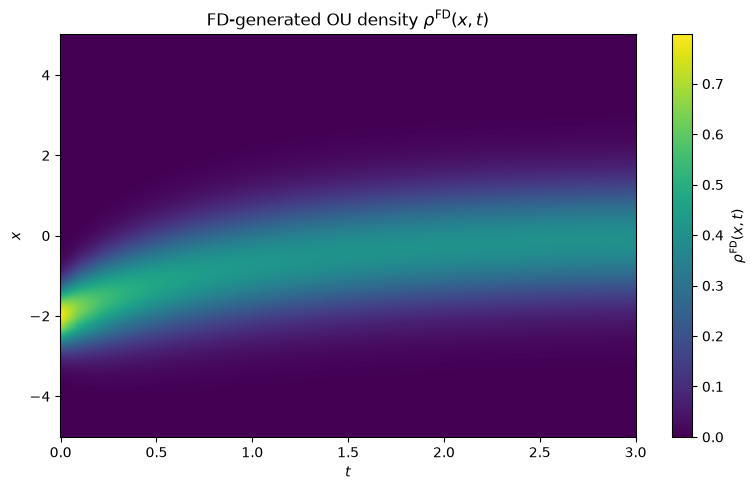

In [7]:
# ============================================================
# 2.5 Check the FD-generated density
# ============================================================

mass_fd = np.trapezoid(
    rho_fd,
    x=x_fd,
    axis=0,
)

print("Minimum mass inside domain:", mass_fd.min())
print("Maximum mass inside domain:", mass_fd.max())
print("Minimum density:           ", rho_fd.min())
print("Maximum density:           ", rho_fd.max())

fig, ax = plt.subplots(figsize=(8, 5))

plot = ax.pcolormesh(
    t_fd,
    x_fd,
    rho_fd,
    shading="auto",
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(r"FD-generated OU density $\rho^{\mathrm{FD}}(x,t)$")

fig.colorbar(
    plot,
    ax=ax,
    label=r"$\rho^{\mathrm{FD}}(x,t)$",
)

plt.tight_layout()
plt.show()


## Lib 1

In [8]:
# ============================================================
# 2.6 Numerical derivatives computed from rho_fd
# ============================================================

Dt_fd_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_fd_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_fd_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_fd_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the FD-data SINDy target
rho_t_fd = Dt_fd_data(rho_fd, t_fd)

# Numerical spatial derivatives used to construct the FD library
rho_x_fd = Dx_fd_data(rho_fd, x_fd)
rho_square_x_fd = Dx_fd_data(rho_fd**2, x_fd)
rho_cubic_x_fd = Dx_fd_data(rho_fd**3, x_fd)


rho_xx_fd = Dxx_fd_data(rho_fd, x_fd)
rho_square_xx_fd = Dxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xx_fd = Dxx_fd_data(rho_fd**3, x_fd)


rho_xxx_fd = Dxxx_fd_data(rho_fd, x_fd)
rho_square_xxx_fd = Dxxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xxx_fd = Dxxx_fd_data(rho_fd**3, x_fd)

# Conservative drift candidates
d_x_xrho_fd = Dx_fd_data(X_fd * rho_fd, x_fd)
d_x_x2rho_fd = Dx_fd_data(X_fd**2 * rho_fd, x_fd)
d_x_x3rho_fd = Dx_fd_data(X_fd**3 * rho_fd, x_fd)
d_x_xrho_fd2 = Dx_fd_data(X_fd * rho_fd**2,x_fd)
d_x_x2rho_fd2 = Dx_fd_data(X_fd**2 * rho_fd**2,x_fd)



print("rho_t_fd shape:", rho_t_fd.shape)


rho_t_fd shape: (401, 601)


In [9]:
# ============================================================
# 2.7 Candidate library for FD-density data
# ============================================================

candidate_fields_fd = {
    "rho": rho_fd,
    "rho_x": rho_x_fd,
    "d_x(rho^2)": rho_square_x_fd,
    "d_x(rho^3)": rho_cubic_x_fd,

    "d_x(x rho)": d_x_xrho_fd,
    "d_x(x^2 rho)": d_x_x2rho_fd,
    "d_x(x^3 rho)": d_x_x3rho_fd,
    "d_x(x rho^2)": d_x_xrho_fd2,
    "d_x(x^2 rho^2)": d_x_x2rho_fd2,
    
    "rho_xx": rho_xx_fd,
    "d_xx(rho^2)": rho_square_xx_fd,
    "d_xx(rho^3)": rho_cubic_xx_fd,
    
    "rho_xxx": rho_xxx_fd,
    "d_xxx(rho^2)": rho_square_xxx_fd,
    "d_xxx(rho^3)": rho_cubic_xxx_fd,
    
}

feature_names_fd = list(candidate_fields_fd.keys())

true_coefficients_fd = np.array([
    0.0,       # rho
    0.0,       # rho_square_x
    0.0,       # rho_cubic_x
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    0.0,       # d_x(x^3 rho)
    0.0,       # d_x(x rho^2)
    0.0,       # d_x(x^2 rho^2)
    D,         # rho_xx
    0.0,       # rho_square_xx
    0.0,       # rho_square_xx
    0.0,       # rho_xxx
    0.0,       # rho_square_xxx
    0.0,       # rho_cubic_xxx
])


In [10]:
# ============================================================
# 2.8 Interior fitting region and sparse regression
# ============================================================

space_slice_fd = slice(4, -4)
time_slice_fd = slice(2, -2)

Theta_fd = np.column_stack([
    field[space_slice_fd, time_slice_fd].ravel()
    for field in candidate_fields_fd.values()
])

rho_t_fd_vector = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
].ravel().reshape(-1, 1)

optimizer_fd = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_fd.fit(
    Theta_fd,
    rho_t_fd_vector,
)

coefficients_fd = optimizer_fd.coef_.reshape(-1)

print("Theta_fd shape:       ", Theta_fd.shape)
print("rho_t_fd target shape:", rho_t_fd_vector.shape)


Theta_fd shape:        (234621, 15)
rho_t_fd target shape: (234621, 1)


In [11]:
# ============================================================
# 2.9 Identified FD-data coefficients and PDE
# ============================================================

coefficient_table_fd = pd.DataFrame({
    "Candidate term": feature_names_fd,
    "Identified coefficient": coefficients_fd,
    "True coefficient": true_coefficients_fd,
    "Absolute error": np.abs(
        coefficients_fd - true_coefficients_fd
    ),
})

display(
    coefficient_table_fd.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from FD density")
)

print_identified_equation(
    feature_names_fd,
    coefficients_fd,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(rho^2),0.000000,0.000000,0.000e+00
3,d_x(rho^3),0.000000,0.000000,0.000e+00
4,d_x(x rho),0.999918,1.000000,8.202e-05
5,d_x(x^2 rho),0.000000,0.000000,0.000e+00
6,d_x(x^3 rho),0.000000,0.000000,0.000e+00
7,d_x(x rho^2),0.000000,0.000000,0.000e+00
8,d_x(x^2 rho^2),0.000000,0.000000,0.000e+00
9,rho_xx,0.999975,1.000000,2.492e-05


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+0.999918) d_x(x rho) (+0.999975) rho_xx


In [12]:
# ============================================================
# 2.10 Reconstruct the FD-data identified derivative
# ============================================================

rho_t_hat_fd = np.zeros_like(rho_t_fd)

for coefficient, field in zip(
    coefficients_fd,
    candidate_fields_fd.values(),
):
    rho_t_hat_fd += coefficient * field

print(r"Constructed rho_t_hat_fd = sum_j coefficient_j * candidate_field_fd_j")
print("rho_t_hat_fd shape:", rho_t_hat_fd.shape)


Constructed rho_t_hat_fd = sum_j coefficient_j * candidate_field_fd_j
rho_t_hat_fd shape: (401, 601)


In [13]:
# ============================================================
# 2.11 Three errors for FD-density identification
# ============================================================

rho_t_fd_interior = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
]

rho_t_hat_fd_interior = rho_t_hat_fd[
    space_slice_fd,
    time_slice_fd,
]

rho_t_exact_fd_interior = rho_t_exact_fd_grid[
    space_slice_fd,
    time_slice_fd,
]

# 1. FD-data derivative error relative to exact dynamics.
#    This contains the FD density error and numerical differentiation error.
error_fd_data = relative_l2_error(
    rho_t_fd_interior,
    rho_t_exact_fd_interior,
)

# 2. SINDy fitting error relative to its actual FD numerical target.
error_fd_fit = relative_l2_error(
    rho_t_hat_fd_interior,
    rho_t_fd_interior,
)

# 3. End-to-end identification error relative to exact dynamics.
error_fd_total = relative_l2_error(
    rho_t_hat_fd_interior,
    rho_t_exact_fd_interior,
)

fd_error_table = pd.DataFrame({
    "Comparison": [
        "FD numerical derivative vs analytical derivative",
        "FD-data SINDy derivative vs FD numerical target",
        "FD-data SINDy derivative vs analytical derivative",
    ],
    "Mathematical quantity": [
        r"rho_t_fd - rho_t_exact",
        r"rho_t_hat_fd - rho_t_fd",
        r"rho_t_hat_fd - rho_t_exact",
    ],
    "Relative L2 error": [
        error_fd_data,
        error_fd_fit,
        error_fd_total,
    ],
    "Meaning": [
        "FD-data and numerical-differentiation error",
        "Sparse-regression fitting error",
        "Total FD-to-identification error",
    ],
})

display(
    fd_error_table.style.format({
        "Relative L2 error": "{:.6e}",
    })
)


,Comparison,Mathematical quantity,Relative L2 error,Meaning
0,FD numerical derivative vs analytical derivative,rho_t_fd - rho_t_exact,5.804681e-05,FD-data and numerical-differentiation error
1,FD-data SINDy derivative vs FD numerical target,rho_t_hat_fd - rho_t_fd,1.343139e-04,Sparse-regression fitting error
2,FD-data SINDy derivative vs analytical derivative,rho_t_hat_fd - rho_t_exact,1.234982e-04,Total FD-to-identification error


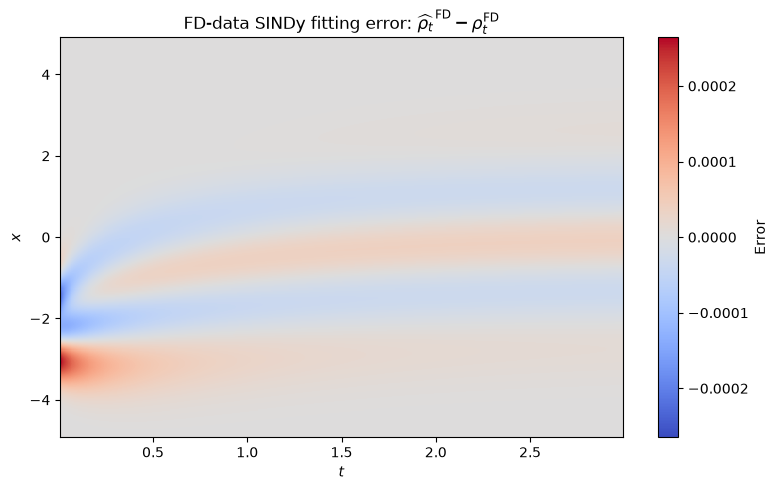

In [14]:
# ============================================================
# 2.12 FD-data heatmap 1: SINDy fitting error
# ============================================================

# prediction minus the numerical target used by SINDy
error_fit_fd_field = (
    rho_t_hat_fd_interior
    - rho_t_fd_interior
)

plot_error_heatmap(
    t_fd[time_slice_fd],
    x_fd[space_slice_fd],
    error_fit_fd_field,
    title=(
        r"FD-data SINDy fitting error: "
        r"$\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}$"
    ),
)


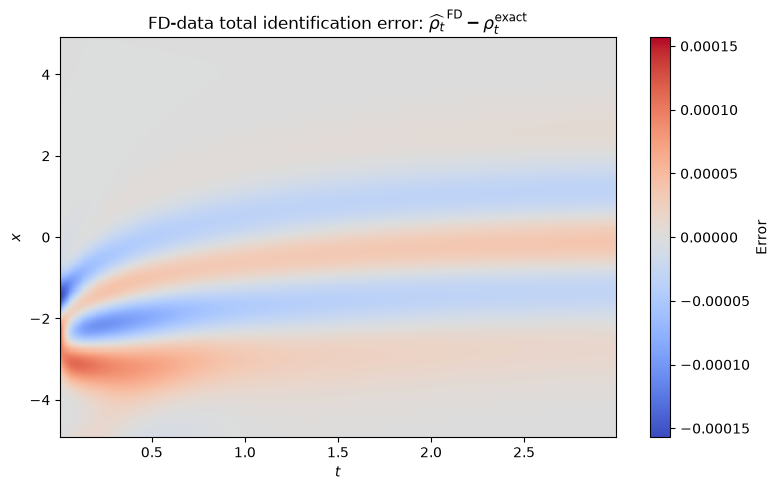

In [15]:
# ============================================================
# 2.13 FD-data heatmap 2: total error relative to exact dynamics
# ============================================================

# prediction minus the analytical reference
error_total_fd_field = (
    rho_t_hat_fd_interior
    - rho_t_exact_fd_interior
)

plot_error_heatmap(
    t_fd[time_slice_fd],
    x_fd[space_slice_fd],
    error_total_fd_field,
    title=(
        r"FD-data total identification error: "
        r"$\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}$"
    ),
)


## Interpretation of the three FD errors

The three relative errors separate the complete pipeline:

$$
\rho_t^{\mathrm{FD}}-\rho_t^{\mathrm{exact}}
$$
measures the discrepancy already present before sparse regression;

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}
$$
measures how accurately SINDy fits its numerical target; and

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}
$$
is the final end-to-end identification error.

Pointwise, the signed errors satisfy

$$
\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{exact}}
=
\left(\widehat{\rho_t}^{\,\mathrm{FD}}-\rho_t^{\mathrm{FD}}\right)
+
\left(\rho_t^{\mathrm{FD}}-\rho_t^{\mathrm{exact}}\right).
$$

Their norms do not generally add because the two component error fields may partially cancel.


## Lib 2

In [16]:
# ============================================================
# 2.6 Numerical derivatives computed from rho_fd
# ============================================================

Dt_fd_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_fd_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_fd_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_fd_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the FD-data SINDy target
rho_t_fd = Dt_fd_data(rho_fd, t_fd)

# Numerical spatial derivatives used to construct the FD library
rho_x_fd = Dx_fd_data(rho_fd, x_fd)
rho_square_x_fd = Dx_fd_data(rho_fd**2, x_fd)
rho_cubic_x_fd = Dx_fd_data(rho_fd**3, x_fd)


rho_xx_fd = Dxx_fd_data(rho_fd, x_fd)
rho_square_xx_fd = Dxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xx_fd = Dxx_fd_data(rho_fd**3, x_fd)


rho_xxx_fd = Dxxx_fd_data(rho_fd, x_fd)
rho_square_xxx_fd = Dxxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xxx_fd = Dxxx_fd_data(rho_fd**3, x_fd)


x_rho_x_fd =  X_fd * Dx_fd_data(rho_fd, x_fd)
x2_rho_x_fd = X_fd**2 * Dx_fd_data(rho_fd, x_fd)
x3_rho_x_fd = X_fd**3 * Dx_fd_data(rho_fd, x_fd)




print("rho_t_fd shape:", rho_t_fd.shape)


rho_t_fd shape: (401, 601)


In [17]:
# ============================================================
# 2.7 Candidate library for FD-density data
# ============================================================

candidate_fields_fd = {
    "rho": rho_fd,
    "rho_x": rho_x_fd,
    "d_x(rho^2)": rho_square_x_fd,
    "d_x(rho^3)": rho_cubic_x_fd,

    "x d_x(rho)": x_rho_x_fd,
    "x^2 d_x(rho)": x2_rho_x_fd,
    "x^3 d_x(rho)": x3_rho_x_fd,
    
    "rho_xx": rho_xx_fd,
    "d_xx(rho^2)": rho_square_xx_fd,
    "d_xx(rho^3)": rho_cubic_xx_fd,
    
    "rho_xxx": rho_xxx_fd,
    "d_xxx(rho^2)": rho_square_xxx_fd,
    "d_xxx(rho^3)": rho_cubic_xxx_fd,
}

feature_names_fd = list(candidate_fields_fd.keys())

true_coefficients_fd = np.array([
    kappa,     # rho
    0.0,       # rho_square_x
    0.0,       # rho_cubic_x
    0.0,       # rho_x
    kappa,     # x d_x(rho)
    0.0,       # x^2 d_x(rho)
    0.0,       # x^3 d_x(rho)
    D,         # rho_xx
    0.0,       # rho_square_xx
    0.0,       # rho_square_xx
    0.0,       # rho_xxx
    0.0,       # rho_square_xxx
    0.0,       # rho_cubic_xxx
])


In [18]:
# ============================================================
# 2.8 Interior fitting region and sparse regression
# ============================================================

space_slice_fd = slice(4, -4)
time_slice_fd = slice(2, -2)

Theta_fd = np.column_stack([
    field[space_slice_fd, time_slice_fd].ravel()
    for field in candidate_fields_fd.values()
])

rho_t_fd_vector = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
].ravel().reshape(-1, 1)

optimizer_fd = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_fd.fit(
    Theta_fd,
    rho_t_fd_vector,
)

coefficients_fd = optimizer_fd.coef_.reshape(-1)

print("Theta_fd shape:       ", Theta_fd.shape)
print("rho_t_fd target shape:", rho_t_fd_vector.shape)


Theta_fd shape:        (234621, 13)
rho_t_fd target shape: (234621, 1)


In [19]:
# ============================================================
# 2.9 Identified FD-data coefficients and PDE
# ============================================================

coefficient_table_fd = pd.DataFrame({
    "Candidate term": feature_names_fd,
    "Identified coefficient": coefficients_fd,
    "True coefficient": true_coefficients_fd,
    "Absolute error": np.abs(
        coefficients_fd - true_coefficients_fd
    ),
})

display(
    coefficient_table_fd.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from FD density")
)

print_identified_equation(
    feature_names_fd,
    coefficients_fd,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.999936,1.000000,6.441e-05
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(rho^2),0.000000,0.000000,0.000e+00
3,d_x(rho^3),0.000000,0.000000,0.000e+00
4,x d_x(rho),0.999916,1.000000,8.351e-05
5,x^2 d_x(rho),0.000000,0.000000,0.000e+00
6,x^3 d_x(rho),0.000000,0.000000,0.000e+00
7,rho_xx,0.999983,1.000000,1.718e-05
8,d_xx(rho^2),0.000000,0.000000,0.000e+00
9,d_xx(rho^3),0.000000,0.000000,0.000e+00


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+0.999936) rho (+0.999916) x d_x(rho) (+0.999983) rho_xx


## Lib 3

In [20]:
# ============================================================
# 2.6 Numerical derivatives computed from rho_fd
# ============================================================

Dt_fd_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_fd_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_fd_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_fd_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the FD-data SINDy target
rho_t_fd = Dt_fd_data(rho_fd, t_fd)

# Numerical spatial derivatives used to construct the FD library
rho_x_fd = Dx_fd_data(rho_fd, x_fd)
rho_square_x_fd = Dx_fd_data(rho_fd**2, x_fd)
rho_cubic_x_fd = Dx_fd_data(rho_fd**3, x_fd)


rho_xx_fd = Dxx_fd_data(rho_fd, x_fd)
rho_square_xx_fd = Dxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xx_fd = Dxx_fd_data(rho_fd**3, x_fd)


rho_xxx_fd = Dxxx_fd_data(rho_fd, x_fd)
rho_square_xxx_fd = Dxxx_fd_data(rho_fd**2, x_fd)
rho_cubic_xxx_fd = Dxxx_fd_data(rho_fd**3, x_fd)


x_rho_x_fd =  X_fd * Dx_fd_data(rho_fd, x_fd)
x2_rho_x_fd = X_fd**2 * Dx_fd_data(rho_fd, x_fd)
x3_rho_x_fd = X_fd**3 * Dx_fd_data(rho_fd, x_fd)

d_x_xrho_fd = Dx_fd_data(X_fd * rho_fd, x_fd)


print("rho_t_fd shape:", rho_t_fd.shape)


rho_t_fd shape: (401, 601)


In [21]:
# ============================================================
# 2.7 Candidate library for FD-density data
# ============================================================

candidate_fields_fd = {
    "rho": rho_fd,
    "rho_x": rho_x_fd,
    "d_x(rho^2)": rho_square_x_fd,
    "d_x(rho^3)": rho_cubic_x_fd,

    "x d_x(rho)": x_rho_x_fd,
    "x^2 d_x(rho)": x2_rho_x_fd,
    "x^3 d_x(rho)": x3_rho_x_fd,
    
    "rho_xx": rho_xx_fd,
    "d_xx(rho^2)": rho_square_xx_fd,
    "d_xx(rho^3)": rho_cubic_xx_fd,
    
    "rho_xxx": rho_xxx_fd,
    "d_xxx(rho^2)": rho_square_xxx_fd,
    "d_xxx(rho^3)": rho_cubic_xxx_fd,
    "d_x(x rho)": d_x_xrho_fd
}

feature_names_fd = list(candidate_fields_fd.keys())

#true_coefficients_fd = np.array([
#    kappa,     # rho
#   0.0,       # rho_square_x
#    0.0,       # rho_cubic_x
#    0.0,       # rho_x
#    kappa,     # x d_x(rho)
#    0.0,       # x^2 d_x(rho)
#    0.0,       # x^3 d_x(rho)
#    D,         # rho_xx
#    0.0,       # rho_square_xx
#    0.0,       # rho_square_xx
#    0.0,       # rho_xxx
#    0.0,       # rho_square_xxx
#    0.0,       # rho_cubic_xxx
#])


In [22]:
# ============================================================
# 2.8 Interior fitting region and sparse regression
# ============================================================

space_slice_fd = slice(4, -4)
time_slice_fd = slice(2, -2)

Theta_fd = np.column_stack([
    field[space_slice_fd, time_slice_fd].ravel()
    for field in candidate_fields_fd.values()
])

rho_t_fd_vector = rho_t_fd[
    space_slice_fd,
    time_slice_fd,
].ravel().reshape(-1, 1)

optimizer_fd = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_fd.fit(
    Theta_fd,
    rho_t_fd_vector,
)

coefficients_fd = optimizer_fd.coef_.reshape(-1)

print("Theta_fd shape:       ", Theta_fd.shape)
print("rho_t_fd target shape:", rho_t_fd_vector.shape)


Theta_fd shape:        (234621, 14)
rho_t_fd target shape: (234621, 1)


In [23]:
# ============================================================
# 2.9 Identified FD-data coefficients and PDE
# ============================================================

coefficient_table_fd = pd.DataFrame({
    "Candidate term": feature_names_fd,
    "Identified coefficient": coefficients_fd,
    #"True coefficient": true_coefficients_fd,
   # "Absolute error": np.abs(
    #    coefficients_fd - true_coefficients_fd
    #),
})

display(
    coefficient_table_fd.style.format({
        "Identified coefficient": "{:.6f}",
    #   "True coefficient": "{:.6f}",
    #    "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from FD density")
)

print_identified_equation(
    feature_names_fd,
    coefficients_fd,
)


,Candidate term,Identified coefficient
0,rho,0.376876
1,rho_x,0.000000
2,d_x(rho^2),0.000000
3,d_x(rho^3),0.000000
4,x d_x(rho),0.376857
5,x^2 d_x(rho),0.000000
6,x^3 d_x(rho),0.000000
7,rho_xx,0.999983
8,d_xx(rho^2),0.000000
9,d_xx(rho^3),0.000000


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+0.376876) rho (+0.376857) x d_x(rho) (+0.999983) rho_xx (+0.623059) d_x(x rho)
